In [1]:
from pathlib import Path
import random
import subprocess
import sys
import zipfile

ROOT = Path("birdclef-2026")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


train.csv shape: (35549, 15)
taxonomy.csv shape: (234, 5)

train.csv columns:
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat



Missing values in train.csv:


primary_label       0
secondary_labels    0
type                0
latitude            0
longitude           0
scientific_name     0
common_name         0
class_name          0
inat_taxon_id       0
author              0
license             0
rating              0
url                 0
filename            0
collection          0
dtype: int64


Using label column: primary_label
Number of unique classes: 206


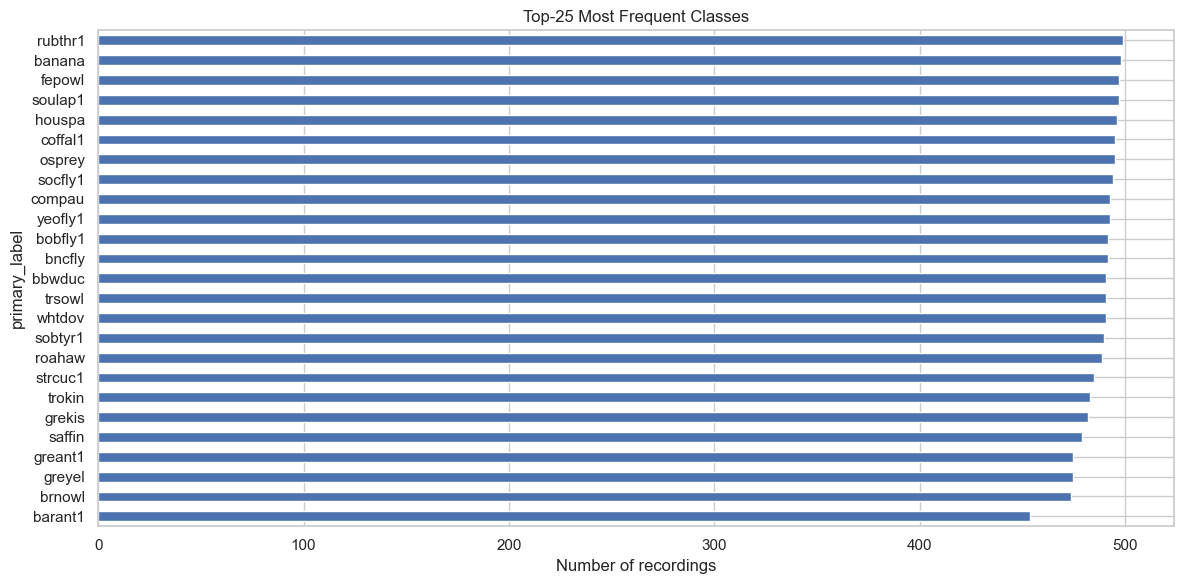


Audio files found: 35549
Example file: birdclef-2026/train_audio/crebec1/XC119358.ogg

Duration stats (sample):


count    2000.000000
mean       35.382384
std        53.232102
min         0.034844
10%         5.932397
25%        10.625430
50%        20.822500
75%        40.798102
90%        73.851791
max       849.084094
Name: duration_sec, dtype: float64

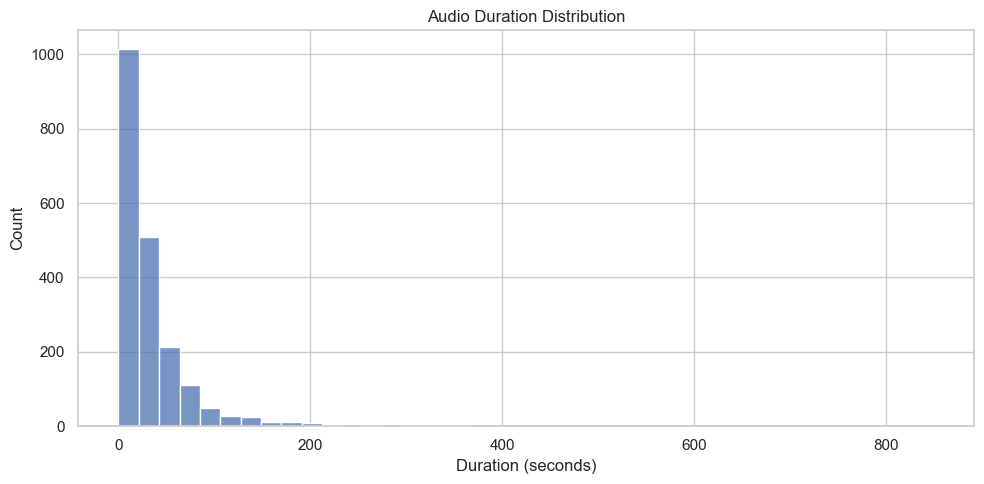


Random sample: XC706738.ogg
Sample rate: 32000 | Duration: 25.46 sec


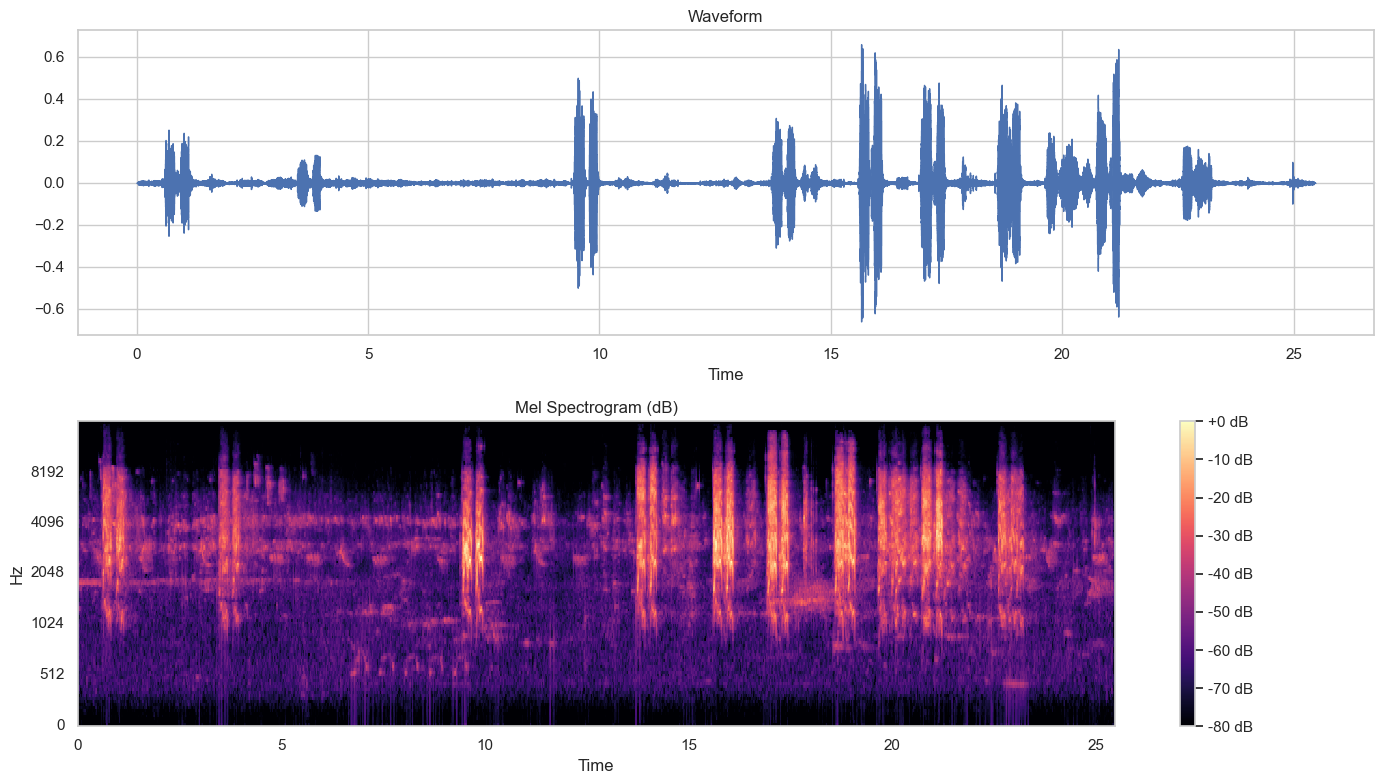

In [ ]:
sns.set_theme(style="whitegrid")

TRAIN_CSV = ROOT / "train.csv"
TAXONOMY_CSV = ROOT / "taxonomy.csv"
TRAIN_AUDIO_DIR = ROOT / "train_audio"

train_df = pd.read_csv(TRAIN_CSV)
taxonomy_df = pd.read_csv(TAXONOMY_CSV)

print("train.csv shape:", train_df.shape)
print("taxonomy.csv shape:", taxonomy_df.shape)
print("\ntrain.csv columns:")
print(train_df.columns.tolist())

display(train_df.head())

print("\nMissing values in train.csv:")
display(train_df.isna().sum().sort_values(ascending=False).head(15))

possible_label_cols = ["primary_label", "species", "scientific_name", "label"]
label_col = next((c for c in possible_label_cols if c in train_df.columns), None)

if label_col is None:
    print("\nCould not find a standard label column.")
    print("Please set `label_col` manually from:", train_df.columns.tolist())
else:
    print(f"\nUsing label column: {label_col}")
    class_counts = train_df[label_col].value_counts()
    print("Number of unique classes:", class_counts.shape[0])

    plt.figure(figsize=(12, 6))
    class_counts.head(25).sort_values().plot(kind="barh")
    plt.title("Top-25 Most Frequent Classes")
    plt.xlabel("Number of recordings")
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()


all_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.ogg"))
if len(all_audio_files) == 0:
    all_audio_files = list(TRAIN_AUDIO_DIR.rglob("*.wav"))

print("\nAudio files found:", len(all_audio_files))
if len(all_audio_files) > 0:
    print("Example file:", all_audio_files[0])

try:
    import soundfile as sf

    sample_for_duration = all_audio_files if len(all_audio_files) <= 2000 else random.sample(all_audio_files, 2000)

    durations = []
    for fp in sample_for_duration:
        try:
            info = sf.info(str(fp))
            durations.append(info.frames / info.samplerate)
        except Exception:
            continue

    if len(durations) > 0:
        duration_series = pd.Series(durations, name="duration_sec")
        print("\nDuration stats (sample):")
        display(duration_series.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

        plt.figure(figsize=(10, 5))
        sns.histplot(duration_series, bins=40)
        plt.title("Audio Duration Distribution")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo durations could be read.")
except Exception as e:
    print("\nSkipping duration section (soundfile not available or failed):", e)


try:
    import librosa
    import librosa.display

    if len(all_audio_files) > 0:
        audio_path = random.choice(all_audio_files)
        y, sr = librosa.load(audio_path, sr=None, mono=True)

        print("\nRandom sample:", audio_path.name)
        print("Sample rate:", sr, "| Duration:", round(len(y) / sr, 2), "sec")

        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        librosa.display.waveshow(y, sr=sr, ax=axes[0])
        axes[0].set_title("Waveform")

        S_db = librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128),
            ref=np.max
        )
        librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
        axes[1].set_title("Mel Spectrogram (dB)")
        plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo audio files found for waveform/spectrogram preview.")
except Exception as e:
    print("", e)

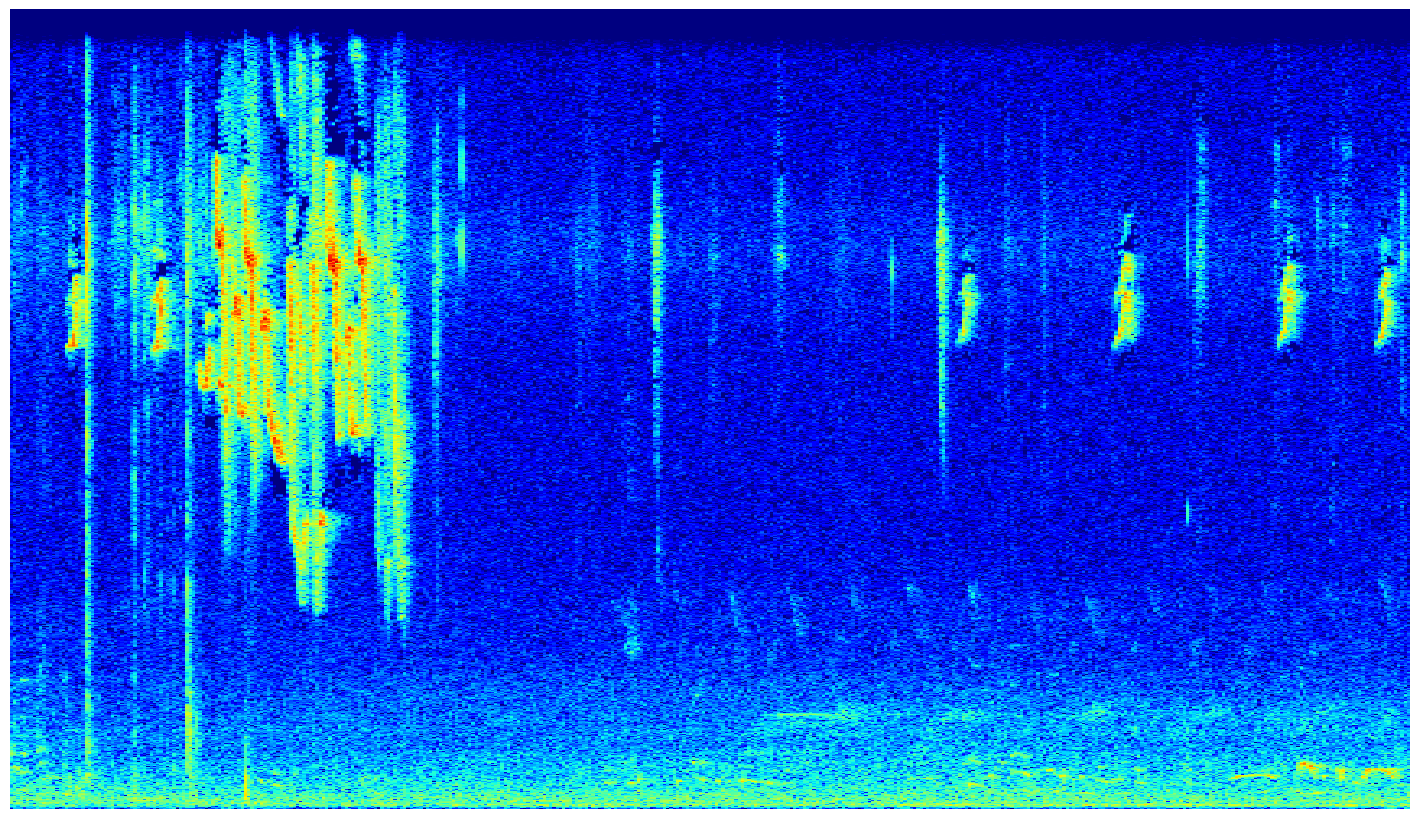

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

y, sr = librosa.load(fp, sr=22050, mono=True)
y = y[: int(20 * sr)] 

n_fft = 2048
hop_length = 1024
S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
S_db = librosa.power_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(14, 8))

librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, cmap="jet", ax=ax)

ax.axis("off")

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
import random
from PIL import Image
from tqdm.auto import tqdm

def generate_clean_spectrograms(
    data,
    chunk_length=7.0,
    sr=32000,
    save_dir_mel=None,
    save_dir_2d=None,
    train_audio_root="birdclef-2026/train_audio",
    n_mels=128,
    n_fft=1024,
    hop_length=256,
    fmin=50,
    fmax=14000,
    power=2.0,
    top_db=80,
    random_chunk=True,
    seed=42,
    mel_cmap="magma",
    linear_cmap="magma",
):
    random.seed(seed)
    np.random.seed(seed)

    if isinstance(data, (str, Path)):
        data = [data]

    train_audio_root = Path(train_audio_root).resolve()

    if save_dir_mel:
        Path(save_dir_mel).mkdir(parents=True, exist_ok=True)
    if save_dir_2d:
        Path(save_dir_2d).mkdir(parents=True, exist_ok=True)

    def _target_path(save_root, fp):
        fp = Path(fp).resolve()
        try:
            rel = fp.relative_to(train_audio_root)
        except ValueError:
            rel = Path(fp.parent.name) / fp.name
        out = Path(save_root) / rel.with_suffix(".png")
        out.parent.mkdir(parents=True, exist_ok=True)
        return out

    # Fast direct-to-image saving function
    def _save_fast_image(S_db, cmap, save_path):
        # Normalize DB array to [0.0, 1.0]
        S_min, S_max = S_db.min(), S_db.max()
        S_norm = (S_db - S_min) / (S_max - S_min + 1e-8)
        
        # Spectrograms have low frequencies at the bottom, images have origin at top-left
        S_norm = np.flipud(S_norm)
        
        # Apply colormap to get RGBA, convert to 8-bit RGB
        img_rgb = (cmap(S_norm)[:, :, :3] * 255).astype(np.uint8)
        
        # Save via PIL
        Image.fromarray(img_rgb).save(save_path)

    # Pre-load colormaps once
    cmap_mel_obj = plt.get_cmap(mel_cmap)
    cmap_lin_obj = plt.get_cmap(linear_cmap)

    errors = []
    saved_count_mel = 0
    saved_count_2d = 0

    for fp in tqdm(data, desc="Generating spectrograms", unit="file"):
        try:
            fp = Path(fp)

            if not fp.exists():
                raise FileNotFoundError(f"Audio file not found: {fp}")

            total_duration = librosa.get_duration(path=str(fp))
            if total_duration <= 0:
                raise ValueError("Audio duration is zero or invalid")

            if total_duration <= chunk_length:
                start_time = 0.0
                duration = total_duration
            else:
                if random_chunk:
                    max_start = total_duration - chunk_length
                    start_time = random.uniform(0, max_start)
                else:
                    start_time = 0.0
                duration = chunk_length

            y, current_sr = librosa.load(
                str(fp),
                sr=sr,
                mono=True,
                offset=start_time,
                duration=duration,
            )

            if y.size == 0:
                raise ValueError("Loaded empty audio chunk")

            expected_samples = int(chunk_length * sr)
            if len(y) < expected_samples:
                padding_length = expected_samples - len(y)
                y = np.pad(y, (0, padding_length), mode='constant')

            peak = np.max(np.abs(y))
            if peak > 0:
                y = y / peak

            S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window="hann")) ** power
            S_db = librosa.power_to_db(S, ref=np.max, top_db=top_db)

            if save_dir_2d:
                save_path_2d = _target_path(save_dir_2d, fp)
                _save_fast_image(S_db, cmap_lin_obj, save_path_2d)
                saved_count_2d += 1
            else:
                fig_2d, ax_2d = plt.subplots(figsize=(12, 6), dpi=150)
                librosa.display.specshow(S_db, sr=current_sr, hop_length=hop_length, x_axis="time", y_axis="linear", cmap=linear_cmap, ax=ax_2d)
                ax_2d.axis("off")
                fig_2d.subplots_adjust(left=0, right=1, bottom=0, top=1)
                plt.show()
                plt.close(fig_2d)

            safe_fmax = min(fmax, current_sr // 2)

            S_mel = librosa.feature.melspectrogram(
                y=y,
                sr=current_sr,
                n_fft=n_fft,
                hop_length=hop_length,
                n_mels=n_mels,
                fmin=fmin,
                fmax=safe_fmax,
                power=power,
                window="hann",
            )
            S_mel_db = librosa.power_to_db(S_mel, ref=np.max, top_db=top_db)

            if save_dir_mel:
                save_path_mel = _target_path(save_dir_mel, fp)
                _save_fast_image(S_mel_db, cmap_mel_obj, save_path_mel)
                saved_count_mel += 1
            else:
                fig_mel, ax_mel = plt.subplots(figsize=(12, 6), dpi=150)
                librosa.display.specshow(S_mel_db, sr=current_sr, hop_length=hop_length, x_axis="time", y_axis="mel", fmin=fmin, fmax=safe_fmax, cmap=mel_cmap, ax=ax_mel)
                ax_mel.axis("off")
                fig_mel.subplots_adjust(left=0, right=1, bottom=0, top=1)
                plt.show()
                plt.close(fig_mel)

        except Exception as e:
            errors.append({"audio_file": str(fp), "error": str(e)})

    return {
        "saved_mel": saved_count_mel,
        "saved_2d": saved_count_2d,
        "errors": errors,
    }

files_to_process = list(Path("birdclef-2026/train_audio").rglob("*.ogg"))

result = generate_clean_spectrograms(
    files_to_process,
    chunk_length=7.0,
    sr=32000,
    save_dir_mel="dataset/mel_spectrograms",
    save_dir_2d="dataset/linear_spectrograms",
    train_audio_root="birdclef-2026/train_audio",
    n_mels=128,
    n_fft=1024,
    hop_length=256,
    fmin=50,
    fmax=14000,
    top_db=80,
    random_chunk=True,
    seed=42,
    mel_cmap="magma",
    linear_cmap="magma",
)

Generating spectrograms:   0%|          | 0/35549 [00:00<?, ?file/s]

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

class BirdSpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform or transforms.Compose([transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        label_tensor = torch.tensor(label, dtype=torch.float32)
        return image, label_tensor

spectrogram_root = Path("dataset/mel_spectrograms")
image_paths = sorted(spectrogram_root.rglob("*.png"))

if len(image_paths) == 0:
    print("No spectrogram PNG files found in dataset/mel_spectrograms.")
    print("Run the spectrogram generation cell first.")
else:
    class_names = sorted({p.parent.name for p in image_paths})
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    labels = [class_to_idx[p.parent.name] for p in image_paths]

    train_dataset = BirdSpectrogramDataset(image_paths=image_paths, labels=labels)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

    for images, batch_labels in train_loader:
        print(f"Batch Image Shape: {images.shape}")
        print(f"Batch Label Shape: {batch_labels.shape}")
        print(f"Classes in mapping: {len(class_to_idx)}")
        break

Batch Image Shape: torch.Size([32, 3, 128, 876])
Batch Label Shape: torch.Size([32])
Classes in mapping: 206


In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("birdclef-2026/train.csv")

unique_birds = sorted(df['primary_label'].unique())
bird_to_index = {bird: idx for idx, bird in enumerate(unique_birds)}
index_to_bird = {idx: bird for idx, bird in enumerate(unique_birds)} 

print(f"Total unique bird classes: {len(unique_birds)}")

image_paths = []
labels = []

mel_dir = Path("dataset/mel_spectrograms")

for _, row in df.iterrows():
    png_filename = str(row['filename']).replace(".ogg", ".png")
    full_png_path = mel_dir / png_filename

    if full_png_path.exists():
        image_paths.append(str(full_png_path))

        int_label = bird_to_index[row['primary_label']]
        labels.append(int_label)

print(f"Found {len(image_paths)} saved spectrograms ready for training.")


Total unique bird classes: 206
Found 35549 saved spectrograms ready for training.


In [ ]:
import torchvision.transforms as transforms
import torchaudio.transforms as T

def get_transforms(use_specaugment=True):
    transform_list = [transforms.ToTensor()]
    
    if use_specaugment:
        transform_list.extend([
            T.FrequencyMasking(freq_mask_param=15),
            T.TimeMasking(time_mask_param=35)
        ])
        
    return transforms.Compose(transform_list)


import torch
import torch.nn.functional as F
import numpy as np

def prepare_batch(images, labels, num_classes, use_mixup=True, alpha=0.2):

    labels_one_hot = F.one_hot(labels.long(), num_classes=num_classes).float()
    if not use_mixup or alpha <= 0:
        return images, labels_one_hot
    lam = np.random.beta(alpha, alpha)
    
    batch_size = images.size(0)
    index = torch.randperm(batch_size).to(images.device)

    mixed_images = lam * images + (1 - lam) * images[index, :]

    mixed_labels = lam * labels_one_hot + (1 - lam) * labels_one_hot[index, :]

    return mixed_images, mixed_labels

In [ ]:
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
EPOCHS = 5  
BATCH_SIZE = 32
NUM_WORKERS = 0
MAX_IMAGES_PER_TYPE = 10000 
VAL_RATIO = 0.2
FREEZE_BACKBONE = True

SPECTROGRAM_DIRS = {
    "mel": Path("dataset/mel_spectrograms"),
    "linear": Path("dataset/linear_spectrograms"),
}

def build_backbone():
    """Return model, weights, model_name with robust fallback by torchvision version."""
    try:
        from torchvision.models import efficientnet_v2_b2, EfficientNet_V2_B2_Weights
        weights = EfficientNet_V2_B2_Weights.IMAGENET1K_V1
        model = efficientnet_v2_b2(weights=weights)
        return model, weights, "efficientnet_v2_b2"
    except Exception:
        from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
        try:
            weights = EfficientNet_B2_Weights.IMAGENET1K_V1
            model = efficientnet_b2(weights=weights)
        except Exception:
            weights = None
            model = efficientnet_b2(weights=None)
        return model, weights, "efficientnet_b2_fallback"

class SpectrogramClassificationDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

def build_transforms(use_augmentation):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    if use_augmentation:
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
            transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15)], p=0.35),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    valid_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return train_tf, valid_tf

def collect_samples(spectrogram_root, max_images=None):
    image_paths = sorted(spectrogram_root.rglob("*.png"))
    if len(image_paths) == 0:
        return [], []

    raw_classes = [p.parent.name for p in image_paths]

    if max_images is not None and len(image_paths) > max_images:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(image_paths), size=max_images, replace=False)
        idx = np.sort(idx)
        image_paths = [image_paths[i] for i in idx]
        raw_classes = [raw_classes[i] for i in idx]

    counts = pd.Series(raw_classes).value_counts()
    keep_classes = set(counts[counts >= 2].index.tolist())
    keep_idx = [i for i, c in enumerate(raw_classes) if c in keep_classes]
    image_paths = [image_paths[i] for i in keep_idx]
    raw_classes = [raw_classes[i] for i in keep_idx]

    class_names = sorted(set(raw_classes))
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    labels = [class_to_idx[c] for c in raw_classes]

    return image_paths, labels

def train_one_setting(spec_name, root_dir, use_aug, epochs=5):
    image_paths, labels = collect_samples(root_dir, max_images=MAX_IMAGES_PER_TYPE)
    if len(image_paths) == 0:
        return {
            "spectrogram": spec_name,
            "augmentation": use_aug,
            "status": "no_data",
            "backbone": "n/a",
            "split_mode": "n/a",
            "train_samples": 0,
            "val_samples": 0,
            "best_val_acc": np.nan,
            "best_val_loss": np.nan,
            "time_sec": 0.0,
        }

    if len(set(labels)) < 2 or len(image_paths) < 20:
        return {
            "spectrogram": spec_name,
            "augmentation": use_aug,
            "status": "insufficient_data",
            "backbone": "n/a",
            "split_mode": "n/a",
            "train_samples": len(image_paths),
            "val_samples": 0,
            "best_val_acc": np.nan,
            "best_val_loss": np.nan,
            "time_sec": 0.0,
        }

    split_mode = "stratified"
    try:
        train_paths, val_paths, train_labels, val_labels = train_test_split(
            image_paths,
            labels,
            test_size=VAL_RATIO,
            random_state=SEED,
            stratify=labels,
        )
    except ValueError:
        split_mode = "random_fallback"
        adaptive_test = min(0.5, max(VAL_RATIO, (len(set(labels)) + 2) / max(len(labels), 1)))
        train_paths, val_paths, train_labels, val_labels = train_test_split(
            image_paths,
            labels,
            test_size=adaptive_test,
            random_state=SEED,
            stratify=None,
        )

    model, _, model_name = build_backbone()
    train_tf, val_tf = build_transforms(use_augmentation=use_aug)

    train_ds = SpectrogramClassificationDataset(train_paths, train_labels, transform=train_tf)
    val_ds = SpectrogramClassificationDataset(val_paths, val_labels, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    num_classes = len(set(labels))
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    if FREEZE_BACKBONE:
        for name, param in model.named_parameters():
            if not name.startswith("classifier"):
                param.requires_grad = False

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3,
        weight_decay=1e-4,
    )

    best_val_acc = -1.0
    best_val_loss = np.inf
    best_state = None

    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss_sum += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += xb.size(0)

        val_loss = val_loss_sum / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - t0
    return {
        "spectrogram": spec_name,
        "augmentation": use_aug,
        "status": "ok",
        "backbone": model_name,
        "split_mode": split_mode,
        "train_samples": len(train_ds),
        "val_samples": len(val_ds),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "time_sec": elapsed,
    }

print(f"Device: {DEVICE}")
print(f"Epochs per run: {EPOCHS}")
print(f"Max images per spectrogram type: {MAX_IMAGES_PER_TYPE}")
print(f"Freeze backbone: {FREEZE_BACKBONE}")

results = []
settings = [(spec, aug) for spec in SPECTROGRAM_DIRS.keys() for aug in [False, True]]

for spec_name, use_aug in tqdm(settings, desc="Experiment settings", unit="setting"):
    out = train_one_setting(
        spec_name=spec_name,
        root_dir=SPECTROGRAM_DIRS[spec_name],
        use_aug=use_aug,
        epochs=EPOCHS,
    )
    results.append(out)

results_df = pd.DataFrame(results).sort_values(["spectrogram", "augmentation"]).reset_index(drop=True)
display(results_df)

Device: mps
Epochs per run: 5
Max images per spectrogram type: 10000
Freeze backbone: True


Experiment settings:   0%|          | 0/4 [00:00<?, ?setting/s]

,spectrogram,augmentation,status,backbone,split_mode,train_samples,val_samples,best_val_acc,best_val_loss,time_sec
0,linear,False,ok,efficientnet_b2_fallback,stratified,7989,1998,0.149650,4.213004,583.937670
1,linear,True,ok,efficientnet_b2_fallback,stratified,7989,1998,0.144645,4.212972,583.307855
2,mel,False,ok,efficientnet_b2_fallback,stratified,7989,1998,0.178178,4.002939,323.519536
3,mel,True,ok,efficientnet_b2_fallback,stratified,7989,1998,0.031031,4.969866,353.427075


In [ ]:
import copy
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm


if not torch.backends.mps.is_available():
    raise RuntimeError("MPS is required for this benchmark. Enable Apple Silicon GPU acceleration and rerun.")

DEVICE = torch.device("mps")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EPOCHS = 5
BATCH_SIZE = 32
NUM_WORKERS = 0
VAL_RATIO = 0.2
MAX_IMAGES = 10000
FREEZE_BACKBONE = True

SPECTROGRAM_DIRS = {
    "mel": Path("dataset/mel_spectrograms"),
    "linear": Path("dataset/linear_spectrograms"),
}

def build_model_fn(name, num_classes):
    if name == "efficientnet_b2":
        from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
        model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        return model

    if name == "convnext_tiny":
        from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
        return model

    if name == "resnet50":
        from torchvision.models import resnet50, ResNet50_Weights
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        return model

    if name == "mobilenet_v3_large":
        from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unsupported model: {name}")

if "zoo_results_df" in globals() and isinstance(zoo_results_df, pd.DataFrame) and len(zoo_results_df) > 0:
    ok_prev = zoo_results_df[zoo_results_df["status"] == "ok"]
    if len(ok_prev) > 0:
        best_prev = ok_prev.sort_values("best_val_acc", ascending=False).iloc[0]
        BASE_MODEL = str(best_prev["model"])
        BEST_SPEC = str(best_prev["spectrogram"])
        print(f"Base model from previous best: {BASE_MODEL}")
    else:
        BASE_MODEL = "convnext_tiny"
        BEST_SPEC = "mel"
else:
    BASE_MODEL = "convnext_tiny"
    BEST_SPEC = "mel"

if BEST_SPEC not in SPECTROGRAM_DIRS:
    BEST_SPEC = "mel"

class SpectrogramDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, y

def build_transforms(use_augmentation=False):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    if use_augmentation:
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15)], p=0.35),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    val_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return train_tf, val_tf

def collect_paths(root_dir, max_images=None):
    paths = sorted(Path(root_dir).rglob("*.png"))
    if max_images is not None and len(paths) > max_images:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(paths), size=max_images, replace=False)
        idx = np.sort(idx)
        paths = [paths[i] for i in idx]
    return paths

def per_folder_split_80_20(paths, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    by_class = {}
    for p in paths:
        cls = p.parent.name
        by_class.setdefault(cls, []).append(p)

    train_paths, val_paths = [], []
    for cls, cls_paths in by_class.items():
        cls_paths = list(cls_paths)
        rng.shuffle(cls_paths)
        n = len(cls_paths)
        if n < 2:
            train_paths.extend(cls_paths)
            continue

        n_val = max(1, int(round(n * val_ratio)))
        if n_val >= n:
            n_val = n - 1

        val_paths.extend(cls_paths[:n_val])
        train_paths.extend(cls_paths[n_val:])

    return train_paths, val_paths

def make_labels(train_paths, val_paths):
    classes = sorted({p.parent.name for p in train_paths + val_paths})
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_train = [class_to_idx[p.parent.name] for p in train_paths]
    y_val = [class_to_idx[p.parent.name] for p in val_paths]
    return y_train, y_val, class_to_idx

def build_scheduler(optimizer, scheduler_name, epochs):
    if scheduler_name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    if scheduler_name == "half_cosine":
        def lr_lambda(ep):
            progress = ep / max(epochs - 1, 1)
            if progress <= 0.5:
                return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * (progress / 0.5)))
            return 0.1
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    raise ValueError(f"Unknown scheduler: {scheduler_name}")

def compute_loss(logits, y, loss_name, num_classes):
    if loss_name == "CrossEntropyLoss":
        return nn.CrossEntropyLoss()(logits, y)
    if loss_name == "BCEWithLogitsLoss":
        y_oh = F.one_hot(y, num_classes=num_classes).float()
        return nn.BCEWithLogitsLoss()(logits, y_oh)
    raise ValueError(f"Unknown loss: {loss_name}")

def train_eval_config(model_name, train_loader, val_loader, num_classes, epochs, scheduler_name, loss_name, freeze_backbone=True):
    model = build_model_fn(model_name, num_classes)

    if freeze_backbone:
        for n, p in model.named_parameters():
            is_head = n.startswith("classifier") or n.startswith("fc")
            if not is_head:
                p.requires_grad = False

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
    scheduler = build_scheduler(optimizer, scheduler_name=scheduler_name, epochs=epochs)

    best_val_acc = -1.0
    best_val_loss = np.inf
    best_state = None
    t0 = time.time()

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = compute_loss(logits, yb, loss_name=loss_name, num_classes=num_classes)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = compute_loss(logits, yb, loss_name=loss_name, num_classes=num_classes)
                val_loss_sum += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += xb.size(0)

        val_loss = val_loss_sum / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "model": model_name,
        "scheduler": scheduler_name,
        "loss": loss_name,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "time_sec": time.time() - t0,
    }

root_dir = SPECTROGRAM_DIRS[BEST_SPEC]
all_paths = collect_paths(root_dir, max_images=MAX_IMAGES)

if len(all_paths) < 40:
    raise ValueError("Not enough spectrogram images found for tuning.")

train_paths, val_paths = per_folder_split_80_20(all_paths, val_ratio=VAL_RATIO, seed=SEED)
train_labels, val_labels, class_to_idx = make_labels(train_paths, val_paths)
num_classes = len(class_to_idx)

train_tf, val_tf = build_transforms(use_augmentation=False)
train_ds = SpectrogramDataset(train_paths, train_labels, transform=train_tf)
val_ds = SpectrogramDataset(val_paths, val_labels, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Device: {DEVICE}")
print(f"Base model: {BASE_MODEL}")
print(f"Spectrogram: {BEST_SPEC}")
print(f"Split per folder 80/20 => train={len(train_ds)} val={len(val_ds)} classes={num_classes}")
print(f"Epochs: {EPOCHS}")

configs = [
    ("cosine", "CrossEntropyLoss"),
    ("half_cosine", "CrossEntropyLoss"),
    ("cosine", "BCEWithLogitsLoss"),
    ("half_cosine", "BCEWithLogitsLoss"),
]

tuning_rows = []
for scheduler_name, loss_name in tqdm(configs, desc="Scheduler/Loss tuning", unit="cfg"):
    row = train_eval_config(
        model_name=BASE_MODEL,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=num_classes,
        epochs=EPOCHS,
        scheduler_name=scheduler_name,
        loss_name=loss_name,
        freeze_backbone=FREEZE_BACKBONE,
    )
    row.update({
        "status": "ok",
        "spectrogram": BEST_SPEC,
        "freeze_backbone": FREEZE_BACKBONE,
        "train_samples": len(train_ds),
        "val_samples": len(val_ds),
        "epochs": EPOCHS,
    })
    tuning_rows.append(row)

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
display(tuning_df)

Base model from previous best: efficientnet_b2
Device: mps
Base model: efficientnet_b2
Spectrogram: mel
Split per folder 80/20 => train=8001 val=1999 classes=198
Epochs: 5


Scheduler/Loss tuning:   0%|          | 0/4 [00:00<?, ?cfg/s]

,model,scheduler,loss,best_val_acc,best_val_loss,time_sec,status,spectrogram,freeze_backbone,train_samples,val_samples,epochs
0,efficientnet_b2,cosine,CrossEntropyLoss,0.164582,4.136887,345.332551,ok,mel,True,8001,1999,5
1,efficientnet_b2,half_cosine,CrossEntropyLoss,0.159080,4.259478,368.746143,ok,mel,True,8001,1999,5
2,efficientnet_b2,cosine,BCEWithLogitsLoss,0.149575,0.048840,371.728856,ok,mel,True,8001,1999,5
3,efficientnet_b2,half_cosine,BCEWithLogitsLoss,0.120560,0.061445,419.260430,ok,mel,True,8001,1999,5


In [ ]:
import copy
import time
import pandas as pd
import torch
from tqdm.auto import tqdm

if not torch.backends.mps.is_available():
    raise RuntimeError("MPS is required for this run.")

DEVICE = torch.device("mps")

required_vars = [
    "tuning_df",
    "build_model_fn",
    "build_scheduler",
    "compute_loss",
    "train_loader",
    "val_loader",
    "num_classes",
]
for v in required_vars:
    if v not in globals():
        raise ValueError(f"Missing required variable: {v}. Run the tuning cell first.")

ok_tuning = tuning_df[tuning_df["status"] == "ok"].copy()
if len(ok_tuning) == 0:
    raise ValueError("No successful tuning runs found.")

best_cfg = ok_tuning.sort_values("best_val_acc", ascending=False).iloc[0]
best_scheduler = str(best_cfg["scheduler"])
best_loss = str(best_cfg["loss"])
best_model_name = str(best_cfg["model"])
print(f"Selected for unfreezing => model={best_model_name}, scheduler={best_scheduler}, loss={best_loss}")

model = build_model_fn(best_model_name, num_classes=num_classes)
for p in model.parameters():
    p.requires_grad = True
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
UNFREEZE_EPOCHS = 5
scheduler = build_scheduler(optimizer, scheduler_name=best_scheduler, epochs=UNFREEZE_EPOCHS)

best_val_acc = -1.0
best_state = None
history = []
t0 = time.time()

for epoch in range(1, UNFREEZE_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in tqdm(train_loader, desc=f"Unfreeze train epoch {epoch}", leave=False):
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = compute_loss(logits, yb, loss_name=best_loss, num_classes=num_classes)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total += xb.size(0)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = compute_loss(logits, yb, loss_name=best_loss, num_classes=num_classes)
            val_loss_sum += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb).sum().item()
            val_total += xb.size(0)

    train_loss = train_loss_sum / max(train_total, 1)
    train_acc = train_correct / max(train_total, 1)
    val_loss = val_loss_sum / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
        "scheduler": best_scheduler,
        "loss": best_loss,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)

elapsed = time.time() - t0
unfreeze_history_df = pd.DataFrame(history)
display(unfreeze_history_df)
print(f"Best validation accuracy after unfreezing: {best_val_acc:.4f}")
print(f"Elapsed time (sec): {elapsed:.2f}")

Selected for unfreezing => model=efficientnet_b2, scheduler=cosine, loss=CrossEntropyLoss


Unfreeze train epoch 1:   0%|          | 0/251 [00:00<?, ?it/s]

Unfreeze train epoch 2:   0%|          | 0/251 [00:00<?, ?it/s]

Unfreeze train epoch 3:   0%|          | 0/251 [00:00<?, ?it/s]

Unfreeze train epoch 4:   0%|          | 0/251 [00:00<?, ?it/s]

Unfreeze train epoch 5:   0%|          | 0/251 [00:00<?, ?it/s]

,epoch,train_loss,train_acc,val_loss,val_acc,lr,scheduler,loss
0,1,4.582876,0.101987,3.759934,0.229615,0.000181,cosine,CrossEntropyLoss
1,2,3.196390,0.322085,2.984074,0.362681,0.000131,cosine,CrossEntropyLoss
2,3,2.355874,0.490064,2.632355,0.431716,0.000070,cosine,CrossEntropyLoss
3,4,1.833902,0.603800,2.487920,0.470735,0.000020,cosine,CrossEntropyLoss
4,5,1.559386,0.673666,2.478051,0.469735,0.000001,cosine,CrossEntropyLoss


Best validation accuracy after unfreezing: 0.4707
Elapsed time (sec): 1214.58
